# KV Cache 优化：LLM 推理加速的核心技术

## 📌 核心问题

在自回归生成中，每次生成新 token 都需要 attend 到所有历史 token：

**问题**：历史 token 的 K, V 被重复计算 → O(n²) 复杂度  
**解决方案**：KV Cache → O(n) 复杂度

## 🎯 KV Cache 核心原理

| 维度 | 说明 |
|------|------|
| **数据结构** | 预分配 tensor: [batch, heads, max_len, dim] |
| **核心操作** | cache[start:end] = new_kv（原地更新） |
| **两阶段** | Prefill（初始化）+ Decode（增量更新） |
| **收益** | 速度提升 5-10x，复杂度 O(n²) → O(n) |

In [1]:
# 1. 导入库
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.kv_cache import KVCache, MultiHeadAttentionWithCache
from src.attention import MultiHeadAttention

# 设置中文字体
# Font settings removed for compatibility
plt.rcParams['axes.unicode_minus'] = False 

# 设置绘图样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

torch.manual_seed(42)
print("环境Initialization完成")

环境Initialization完成


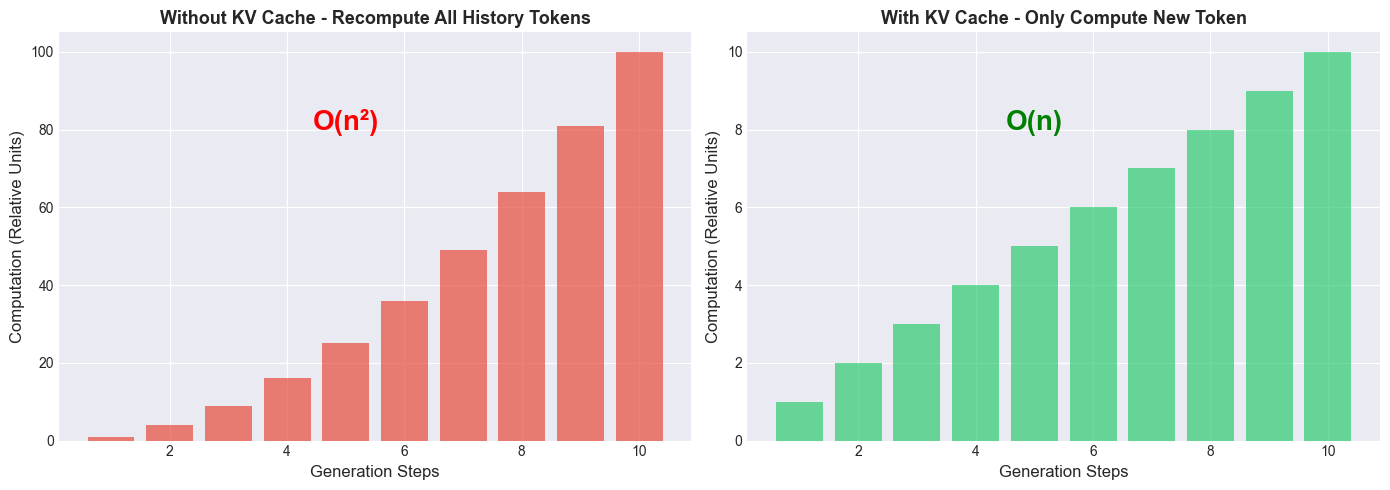

At step 10:
   Without Cache: 100 computation units
   With Cache:   10 computation units
   Reduction: 90%


In [2]:
# 2. 可视化：有无 KV Cache 的计算差异

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：不使用 KV Cache
steps = np.arange(1, 11)
compute_no_cache = steps * steps  # O(n²)

ax1.bar(steps, compute_no_cache, color='#e74c3c', alpha=0.7)
ax1.set_xlabel('Generation Steps', fontsize=12)
ax1.set_ylabel('Computation (Relative Units)', fontsize=12)
ax1.set_title('Without KV Cache - Recompute All History Tokens', fontsize=13, fontweight='bold')
ax1.text(5, max(compute_no_cache)*0.8, 'O(n²)', fontsize=20, ha='center', color='red', fontweight='bold')

# 右图：使用 KV Cache
compute_with_cache = steps  # O(n)

ax2.bar(steps, compute_with_cache, color='#2ecc71', alpha=0.7)
ax2.set_xlabel('Generation Steps', fontsize=12)
ax2.set_ylabel('Computation (Relative Units)', fontsize=12)
ax2.set_title('With KV Cache - Only Compute New Token', fontsize=13, fontweight='bold')
ax2.text(5, max(compute_with_cache)*0.8, 'O(n)', fontsize=20, ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"At step 10:")
print(f"   Without Cache: {compute_no_cache[-1]} computation units")
print(f"   With Cache:   {compute_with_cache[-1]} computation units")
print(f"   Reduction: {(1 - compute_with_cache[-1]/compute_no_cache[-1])*100:.0f}%")

## 2. KV Cache 数据结构

KV Cache 本质是一个**预分配的缓冲区**：

```python
k_cache: [batch_size, num_heads, max_seq_len, head_dim]
v_cache: [batch_size, num_heads, max_seq_len, head_dim]
cache_len: int  # 当前已使用的长度
```

**设计要点**：
- 预分配内存，避免动态扩容
- 原地更新，零拷贝
- 增量追踪，支持高效追加

KV Cache Initialization
Cache Capacity: torch.Size([2, 8, 100, 64])
Current Length: 0
Memory Usage: 0.78 MB (fp32)


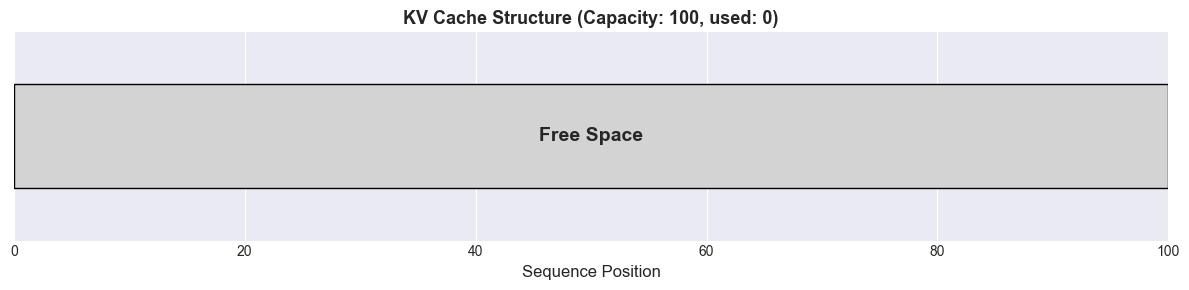

In [3]:
# 3. 创建 KV Cache 并可视化结构

batch_size = 2
num_heads = 8
max_seq_len = 100
head_dim = 64

cache = KVCache(batch_size, num_heads, max_seq_len, head_dim)

print("=" * 60)
print("KV Cache Initialization")
print("=" * 60)
print(f"Cache Capacity: {cache.k_cache.shape}")
print(f"Current Length: {cache.cache_len}")
print(f"Memory Usage: {cache.k_cache.numel() * 2 * 4 / 1024 / 1024:.2f} MB (fp32)")
print("=" * 60)

# 可视化缓存结构
fig, ax = plt.subplots(figsize=(12, 3))

total_slots = max_seq_len
used_slots = cache.cache_len
colors = ['lightgray'] * total_slots

ax.barh(0, total_slots, height=0.5, color=colors, edgecolor='black', linewidth=1)
ax.set_xlim(0, total_slots)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Sequence Position', fontsize=12)
ax.set_title(f'KV Cache Structure (Capacity: {max_seq_len}, used: {used_slots})', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.text(total_slots/2, 0, 'Free Space', ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. cache.update() 核心操作

`cache.update()` 是 KV Cache 的核心方法，分 5 个步骤：

```python
def update(key, value, start_pos=None):
    # 1. 确定写入位置
    start_pos = start_pos or cache_len
    
    # 2. 计算写入范围
    seq_len = key.size(2)
    end_pos = start_pos + seq_len
    
    # 3. 原地更新（核心！零拷贝）
    k_cache[:, :, start_pos:end_pos, :] = key
    v_cache[:, :, start_pos:end_pos, :] = value
    
    # 4. 更新长度
    cache_len = end_pos
    
    # 5. 返回有效部分
    return k_cache[:, :, :end_pos, :], v_cache[:, :, :end_pos, :]
```

**关键优化**：
- 切片赋值 → 零拷贝，O(1) 时间
- 自动追踪 → 无需手动管理位置
- 按需返回 → 只返回有效数据

Prefill Phase: Process Prompt
Input: 10  tokens
Operation: cache.update(k_prompt, v_prompt, start_pos=0)
Done: Cache Length 10


C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\2969675564.py:33: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\2969675564.py:33: UserWarning: Glyph 38386 (\N{CJK UNIFIED IDEOGRAPH-95F2}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\jensen\miniconda3\envs\trt-llm-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jensen\miniconda3\envs\trt-llm-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38386 (\N{CJK UNIFIED IDEOGRAPH-95F2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


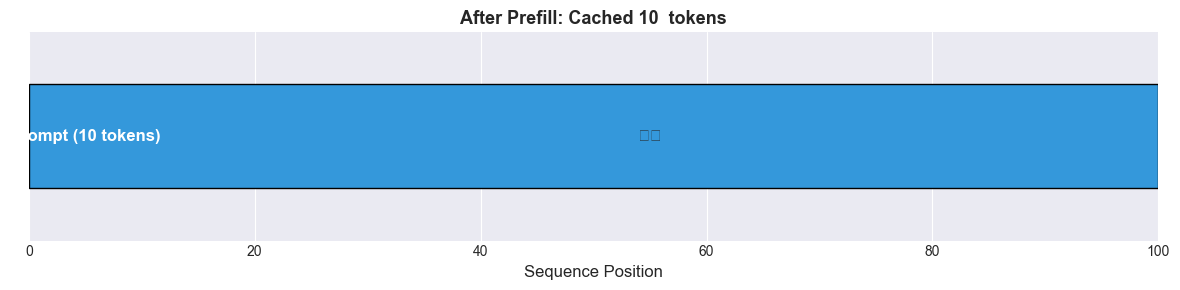

In [4]:
# 4. Prefill 阶段：Initialization缓存

prompt_len = 10
k_prompt = torch.randn(batch_size, num_heads, prompt_len, head_dim)
v_prompt = torch.randn(batch_size, num_heads, prompt_len, head_dim)

print("=" * 60)
print("Prefill Phase: Process Prompt")
print("=" * 60)
print(f"Input: {prompt_len}  tokens")
print(f"Operation: cache.update(k_prompt, v_prompt, start_pos=0)")

k_cached, v_cached = cache.update(k_prompt, v_prompt, start_pos=0)

print(f"Done: Cache Length {cache.cache_len}")
print("=" * 60)

# 可视化 Prefill 后的缓存状态
fig, ax = plt.subplots(figsize=(12, 3))

colors = ['#3498db'] * prompt_len + ['lightgray'] * (max_seq_len - prompt_len)
ax.barh(0, max_seq_len, height=0.5, color=colors, edgecolor='black', linewidth=1)
ax.set_xlim(0, max_seq_len)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Sequence Position', fontsize=12)
ax.set_title(f'After Prefill: Cached {prompt_len}  tokens', fontsize=13, fontweight='bold')
ax.set_yticks([])

# 标注
ax.text(prompt_len/2, 0, f'Prompt ({prompt_len} tokens)', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text((prompt_len + max_seq_len)/2, 0, '空闲', ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Decode Phase: Generate Tokens One by One
Step 1: 缓存 10 -> 11 (Added 1 token)
Step 2: 缓存 11 -> 12 (Added 1 token)
Step 3: 缓存 12 -> 13 (Added 1 token)
Step 4: 缓存 13 -> 14 (Added 1 token)
Step 5: 缓存 14 -> 15 (Added 1 token)


C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1663836048.py:41: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\jensen\miniconda3\envs\trt-llm-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


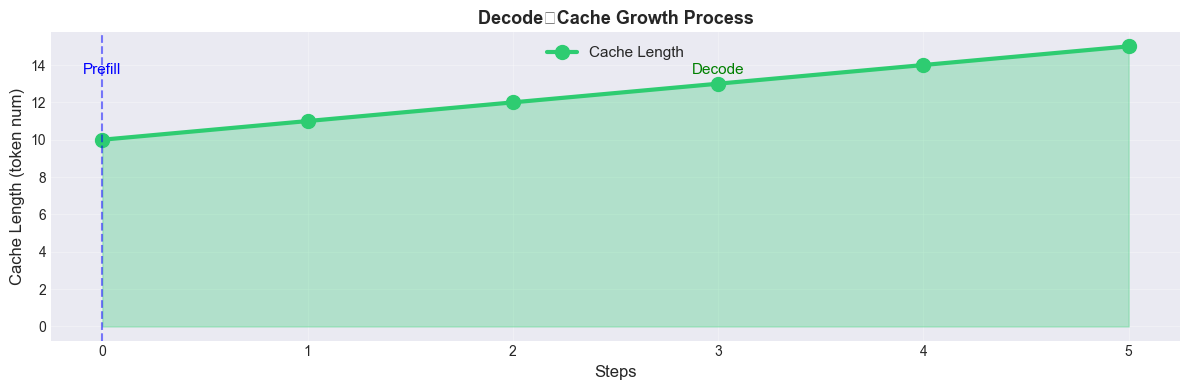

In [5]:
# 5. Decode Phase: Generate Tokens One by One

print("=" * 60)
print("Decode Phase: Generate Tokens One by One")
print("=" * 60)

decode_steps = 5
cache_states = [cache.cache_len]  # 记录每步的Cache Length

for i in range(decode_steps):
    k_new = torch.randn(batch_size, num_heads, 1, head_dim)
    v_new = torch.randn(batch_size, num_heads, 1, head_dim)
    
    prev_len = cache.cache_len
    k_cached, v_cached = cache.update(k_new, v_new)
    
    cache_states.append(cache.cache_len)
    
    print(f"Step {i+1}: 缓存 {prev_len} -> {cache.cache_len} (Added 1 token)")

print("=" * 60)

# 可视化 Decode 过程
fig, ax = plt.subplots(figsize=(12, 4))

steps = list(range(len(cache_states)))
ax.plot(steps, cache_states, 'o-', linewidth=3, markersize=10, color='#2ecc71', label='Cache Length')
ax.fill_between(steps, 0, cache_states, alpha=0.3, color='#2ecc71')

ax.set_xlabel('Steps', fontsize=12)
ax.set_ylabel('Cache Length (token num)', fontsize=12)
ax.set_title('Decode：Cache Growth Process', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# 标注 Prefill 和 Decode 区域
ax.axvline(x=0, color='blue', linestyle='--', alpha=0.5)
ax.text(0, max(cache_states)*0.9, 'Prefill', fontsize=11, ha='center', color='blue')
ax.text(len(steps)/2, max(cache_states)*0.9, 'Decode', fontsize=11, ha='center', color='green')

plt.tight_layout()
plt.show()

Performance testing...
Config: prompt_len=50, gen_len=20



C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1424335665.py:86: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1424335665.py:86: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1424335665.py:86: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1424335665.py:86: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jensen\AppData\Local\Temp\ipykernel_18780\1424335665.py:86: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\jensen\miniconda3\envs\trt-llm-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (

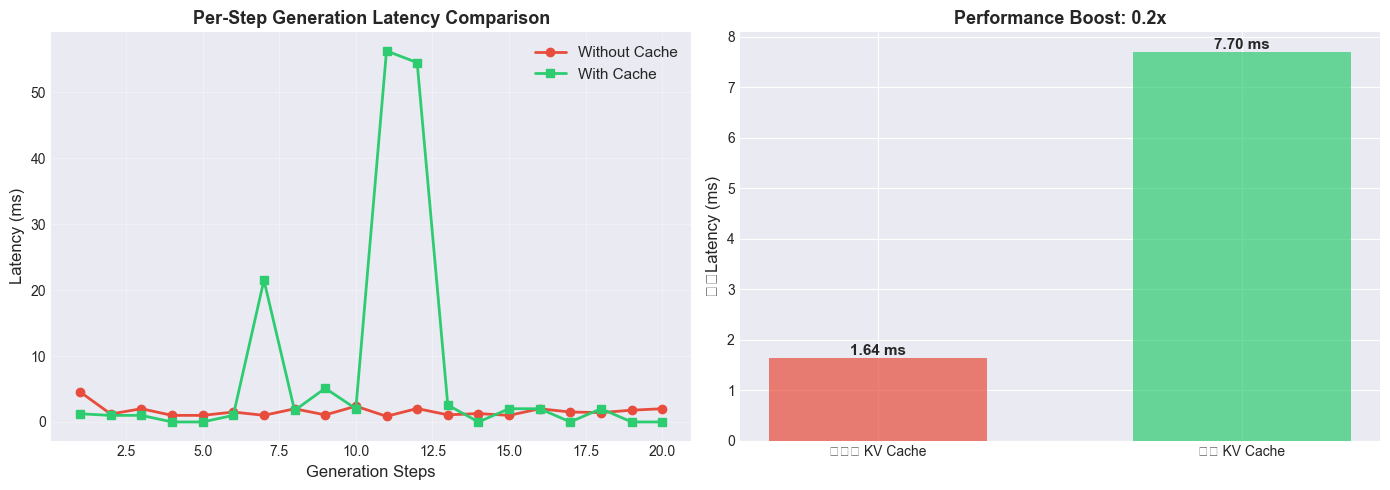

Performance Test Results
Without KV Cache: 1.64 ms/token
With KV Cache:   7.70 ms/token
Speedup: 0.21x


In [6]:
# 6. 性能对比：有 vs 无 KV Cache

def benchmark_without_cache(model, prompt_len, gen_len, d_model):
    tokens = torch.randn(1, prompt_len, d_model)
    times = []
    
    for i in range(gen_len):
        start = time.time()
        with torch.no_grad():
            output, _ = model(tokens, tokens, tokens, use_cache=False)
        times.append((time.time() - start) * 1000)
        
        new_token = torch.randn(1, 1, d_model)
        tokens = torch.cat([tokens, new_token], dim=1)
    
    return times

def benchmark_with_cache(model, prompt_len, gen_len, d_model):
    model.reset_cache()
    
    # Prefill
    prompt = torch.randn(1, prompt_len, d_model)
    with torch.no_grad():
        output, _ = model(prompt, prompt, prompt, use_cache=True, start_pos=0)
    
    # Decode
    times = []
    for i in range(gen_len):
        new_token = torch.randn(1, 1, d_model)
        start = time.time()
        with torch.no_grad():
            output, _ = model(new_token, new_token, new_token, use_cache=True)
        times.append((time.time() - start) * 1000)
    
    return times

# 配置
d_model = 512
num_heads = 8
max_seq_len = 2048
prompt_len = 50
gen_len = 20

model = MultiHeadAttentionWithCache(d_model, num_heads, max_seq_len)
model.eval()

print("Performance testing...")
print(f"Config: prompt_len={prompt_len}, gen_len={gen_len}\n")

# 测试
times_no_cache = benchmark_without_cache(model, prompt_len, gen_len, d_model)
times_with_cache = benchmark_with_cache(model, prompt_len, gen_len, d_model)

# 统计
avg_no_cache = np.mean(times_no_cache)
avg_with_cache = np.mean(times_with_cache)
speedup = avg_no_cache / avg_with_cache

# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：每步延迟
steps = list(range(1, gen_len + 1))
ax1.plot(steps, times_no_cache, 'o-', label='Without Cache', linewidth=2, markersize=6, color='#e74c3c')
ax1.plot(steps, times_with_cache, 's-', label='With Cache', linewidth=2, markersize=6, color='#2ecc71')
ax1.set_xlabel('Generation Steps', fontsize=12)
ax1.set_ylabel('Latency (ms)', fontsize=12)
ax1.set_title('Per-Step Generation Latency Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 右图：性能对比柱状图
categories = ['不使用 KV Cache', '使用 KV Cache']
values = [avg_no_cache, avg_with_cache]
colors_bar = ['#e74c3c', '#2ecc71']

bars = ax2.bar(categories, values, color=colors_bar, alpha=0.7, width=0.6)
ax2.set_ylabel('平均Latency (ms)', fontsize=12)
ax2.set_title(f'Performance Boost: {speedup:.1f}x', fontsize=13, fontweight='bold')

# 添加数值标签
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{val:.2f} ms', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 60)
print("Performance Test Results")
print("=" * 60)
print(f"Without KV Cache: {avg_no_cache:.2f} ms/token")
print(f"With KV Cache:   {avg_with_cache:.2f} ms/token")
print(f"Speedup: {speedup:.2f}x")
print("=" * 60)

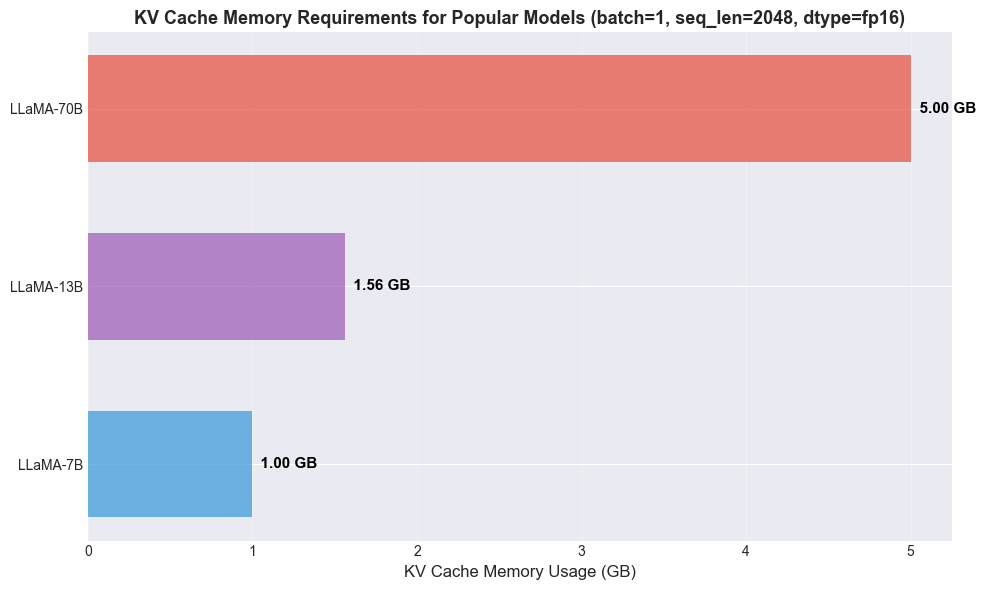

KV Cache Memory Usage
LLaMA-7B    :   1.00 GB
LLaMA-13B   :   1.56 GB
LLaMA-70B   :   5.00 GB
Note: Memory usage doubles when sequence length doubles


In [7]:
# 7. 内存占用分析

def calculate_kv_cache_memory(num_layers, batch_size, num_heads, max_seq_len, head_dim, dtype_bytes):
    memory_bytes = (2 * num_layers * batch_size * num_heads * max_seq_len * head_dim * dtype_bytes)
    return memory_bytes / (1024 ** 3)

# 主流模型配置
models = {
    "LLaMA-7B": {"num_layers": 32, "num_heads": 32, "head_dim": 128},
    "LLaMA-13B": {"num_layers": 40, "num_heads": 40, "head_dim": 128},
    "LLaMA-70B": {"num_layers": 80, "num_heads": 64, "head_dim": 128},
}

batch_size = 1
seq_len = 2048
dtype_bytes = 2  # fp16

# 计算内存
model_names = []
memories = []

for name, config in models.items():
    mem = calculate_kv_cache_memory(config['num_layers'], batch_size, config['num_heads'], seq_len, config['head_dim'], dtype_bytes)
    model_names.append(name)
    memories.append(mem)

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(model_names, memories, color=['#3498db', '#9b59b6', '#e74c3c'], alpha=0.7, height=0.6)
ax.set_xlabel('KV Cache Memory Usage (GB)', fontsize=12)
ax.set_title(f'KV Cache Memory Requirements for Popular Models (batch=1, seq_len={seq_len}, dtype=fp16)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for bar, mem in zip(bars, memories):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'  {mem:.2f} GB', ha='left', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("=" * 60)
print("KV Cache Memory Usage")
print("=" * 60)
for name, mem in zip(model_names, memories):
    print(f"{name:12s}: {mem:6.2f} GB")
print("=" * 60)
print(f"Note: Memory usage doubles when sequence length doubles")

## 8. 总结

### 核心要点

| 方面 | 说明 |
|------|------|
| **原理** | 缓存已计算的 K, V，避免重复计算 |
| **数据结构** | 预分配 tensor + 增量更新 |
| **性能** | 5-10x 加速，O(n²) → O(n) |
| **代价** | 内存占用与序列长度成正比 |

### 优化方向

- **内存瓶颈** → GQA/MQA（减少 KV 头数）
- **超长序列** → PagedAttention（分页管理）
- **极致优化** → 量化（int8/int4）

### 延伸阅读

1. `03_grouped_query_attention.ipynb` - GQA 如何优化 KV Cache
2. `05_flash_attention.ipynb` - IO 优化技术
3. vLLM PagedAttention - 分页管理方案

---

## 恭喜完成！

你现在理解了：
- KV Cache 的核心原理和实现
- Prefill 和 Decode 两阶段工作流程
- 性能收益和内存权衡
- 实际应用中的优化策略